# Projeto: Palmer Penguins Dataset

O **Palmer Penguins Dataset** reúne medidas de 344 pinguins de três espécies (Adelie, Chinstrap e Gentoo), coletadas em três ilhas do arquipélago Palmer, na Antártida. É um substituto moderno e bastante usado para o clássico conjunto Iris, com a vantagem de ter valores ausentes genuínos, perfeito para praticarmos técnicas de imputação.

https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

random_seed = 111

#dados = pd.read_csv("data/penguins.csv
dados = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv")
dados.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [2]:
plt.rcParams['figure.figsize'] = (6, 4)

### Visualização

Distribuição da variável-alvo (species):
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64



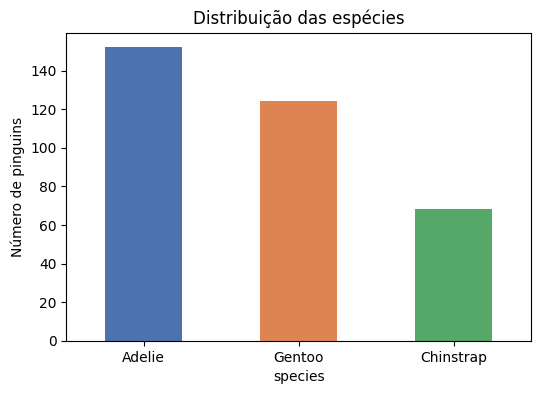

In [3]:
print("Distribuição da variável-alvo (species):")
print(dados["species"].value_counts())
print()
dados["species"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452", "#55A868"])
plt.xticks(rotation=0)
plt.ylabel("Número de pinguins")
plt.title("Distribuição das espécies")
plt.show()

Atributos numéricos e nominais:

In [8]:
atributos_numericos = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
atributos_nominais = ["island", "sex"]

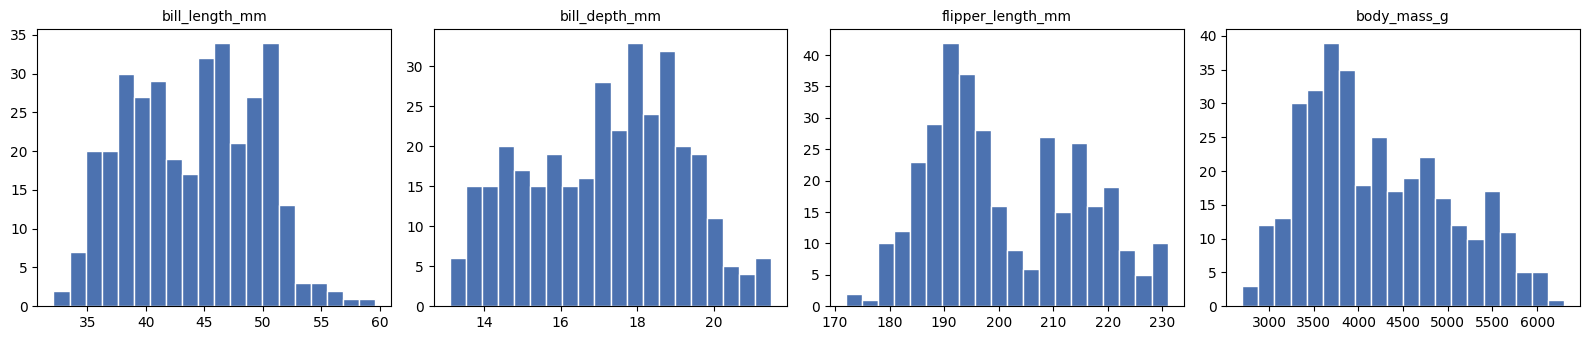

In [9]:
fig, eixos = plt.subplots(1, 4, figsize=(16, 3.5))
for i, atributo in enumerate(atributos_numericos):
    eixos[i].hist(dados[atributo], bins=20, color="#4C72B0", edgecolor="white")
    eixos[i].set_title(atributo, fontsize=10)
plt.tight_layout()
plt.show()

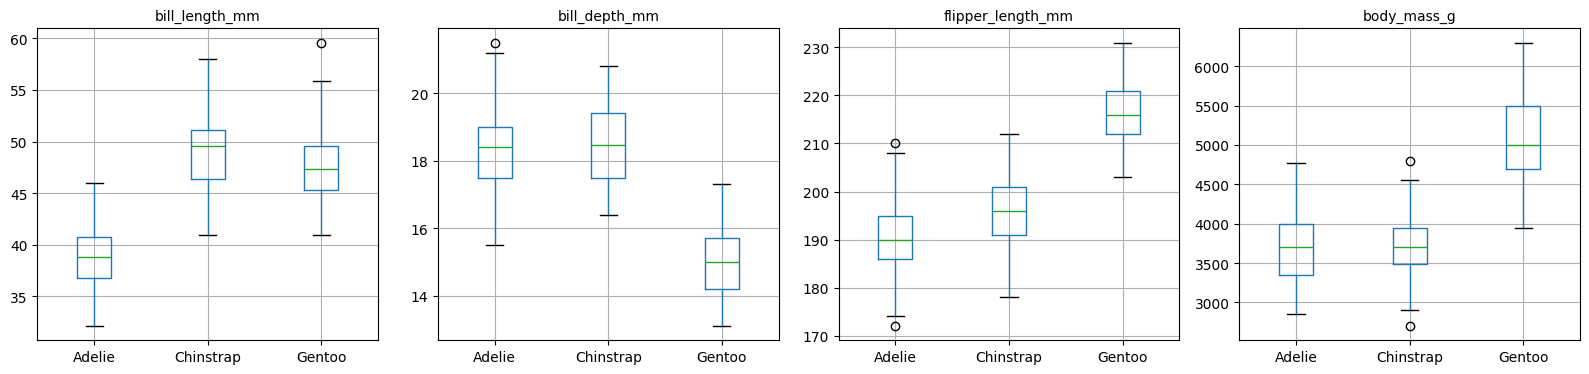

In [10]:
fig, eixos = plt.subplots(1, 4, figsize=(16, 4))
for i, atributo in enumerate(atributos_numericos):
    dados.boxplot(column=atributo, by="species", ax=eixos[i])
    eixos[i].set_title(atributo, fontsize=10)
    eixos[i].set_xlabel("")

plt.suptitle("")
plt.tight_layout()
plt.show()

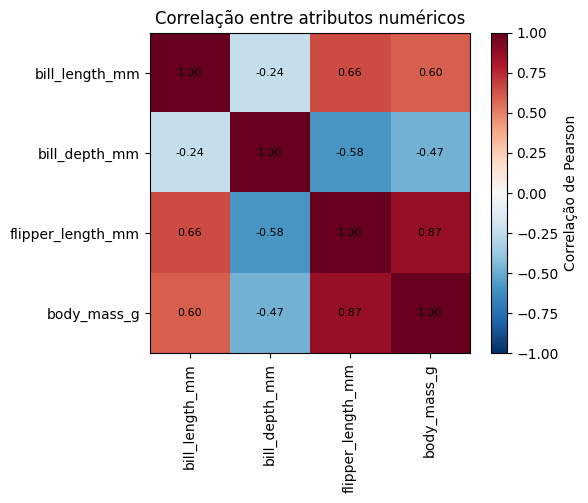

In [11]:
matriz_correlacao = dados[atributos_numericos].corr()

plt.figure(figsize=(6, 5))
plt.imshow(matriz_correlacao, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(label="Correlação de Pearson")
plt.xticks(range(len(matriz_correlacao)), matriz_correlacao.columns, rotation=90)
plt.yticks(range(len(matriz_correlacao)), matriz_correlacao.columns)
for i in range(len(matriz_correlacao)):
    for j in range(len(matriz_correlacao)):
        plt.text(j, i, f"{matriz_correlacao.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.title("Correlação entre atributos numéricos")
plt.tight_layout()
plt.show()

### Tratando os dados ausentes

In [12]:
print(dados.isnull().sum())

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


In [13]:
dados[dados.isnull().any(axis=1)]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN


In [14]:
from sklearn.model_selection import train_test_split

y = dados["species"]
X = dados.drop(columns=["species"])

# separa em treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Treinamento:", X_train.shape)
print("Teste:      ", X_test.shape)

Treinamento: (275, 6)
Teste:       (69, 6)


In [15]:
X_train = pd.get_dummies(X_train, columns= atributos_nominais, drop_first=True)
X_test = pd.get_dummies(X_test, columns= atributos_nominais, drop_first=True).reindex(
    columns=X_train.columns, fill_value=0
)

print("Atributos após a codificação:", list(X_train.columns))
print("\nFormato final -- treino:", X_train.shape, " teste:", X_test.shape)

Atributos após a codificação: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island_Dream', 'island_Torgersen', 'sex_MALE']

Formato final -- treino: (275, 7)  teste: (69, 7)


In [16]:
X_train

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_MALE
98,33.1,16.1,178.0,2900.0,True,False,False
114,39.6,20.7,191.0,3900.0,False,False,False
118,35.7,17.0,189.0,3350.0,False,True,False
303,50.0,15.9,224.0,5350.0,False,False,True
343,49.9,16.1,213.0,5400.0,False,False,True
...,...,...,...,...,...,...,...
10,37.8,17.1,186.0,3300.0,False,True,False
245,46.1,15.1,215.0,5100.0,False,False,True
75,42.8,18.5,195.0,4250.0,False,True,True
82,36.7,18.8,187.0,3800.0,False,True,False


In [17]:
# Calcula a média de cada coluna usando apenas os dados de treinamento.
medias = X_train[atributos_numericos].mean()
print(medias)

# Substitui os valores ausentes no treinamento.
X_train[atributos_numericos] = (X_train[atributos_numericos].fillna(medias))

# Substitui os valores ausentes no teste usando as médias calculadas no conjunto de treinamento.
X_test[atributos_numericos] = (X_test[atributos_numericos].fillna(medias))

bill_length_mm         44.067766
bill_depth_mm          17.170696
flipper_length_mm     200.846154
body_mass_g          4211.263736
dtype: float64


In [18]:
X_train.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_MALE
98,33.1,16.1,178.0,2900.0,True,False,False
114,39.6,20.7,191.0,3900.0,False,False,False
118,35.7,17.0,189.0,3350.0,False,True,False
303,50.0,15.9,224.0,5350.0,False,False,True
343,49.9,16.1,213.0,5400.0,False,False,True


### Padronização

In [19]:
from sklearn.preprocessing import StandardScaler
# Padronizamos os atributos (media 0, desvio 1)
# O scaler e ajustado (fit) apenas no treino, e depois aplicado (transform) tambem ao teste
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Tamanho do treino:", X_train.shape)
print("Tamanho do teste: ", X_test.shape)

Tamanho do treino: (275, 7)
Tamanho do teste:  (69, 7)


### Classificação

In [20]:
from sklearn.metrics import (accuracy_score, confusion_matrix, ConfusionMatrixDisplay)
# Modelos de árvore
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
# K-NN
from sklearn.neighbors import KNeighborsClassifier

In [21]:
# K-NN
k = 21 # numero de vizinhos
# ajusta o modelo k-vizinhos
KNN = KNeighborsClassifier(n_neighbors=k, metric = 'euclidean')
KNN.fit(X_train,y_train)
# faz a predição no conjunto de teste
y_pred_KNN = KNN.predict(X_test)

# Árvore de decisão
Tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    min_samples_leaf=5,
    random_state=random_seed
)
# ajusta o modelo
Tree.fit(X_train, y_train)
# faz a predição no conjunto de teste
y_pred_tree = Tree.predict(X_test)

In [22]:
acc_KNN = accuracy_score(y_test, y_pred_KNN)
print('Acurácia no K-NN:', acc_KNN)
acc_tree = accuracy_score(y_test, y_pred_tree)
print('Acurácia na Árvore de decisão:', acc_tree)

Acurácia no K-NN: 1.0
Acurácia na Árvore de decisão: 0.9855072463768116


[[30  0  0]
 [ 0 14  0]
 [ 0  0 25]]


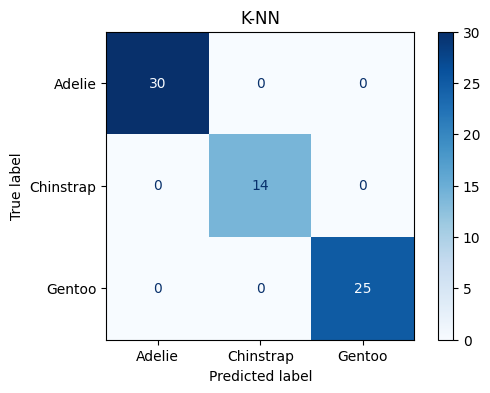

[[29  0  1]
 [ 0 14  0]
 [ 0  0 25]]


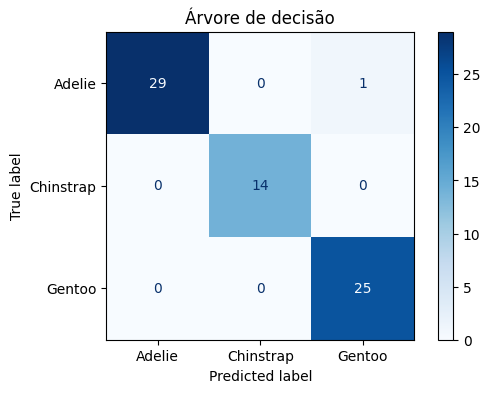

In [23]:
# Matriz de confusão do K-NN
matriz = confusion_matrix(y_test, y_pred_KNN)
print(matriz)
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_KNN,
    cmap=plt.cm.Blues
)
plt.title('K-NN')
plt.show()

# Matriz de confusão da árvore de decisão
matriz = confusion_matrix(y_test, y_pred_tree)
print(matriz)
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tree,
    cmap=plt.cm.Blues
)
plt.title('Árvore de decisão')
plt.show()

ROC-AUC multiclasse: pode ser calculada usando estratégias One-vs-Rest (ovr) ou One-vs-One (ovo).

In [25]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

# ---------------------------------------------------------
# 1. Codificação das classes
# ---------------------------------------------------------
# A métrica ROC-AUC espera que as classes sejam representadas
# numericamente. O LabelEncoder converte os rótulos originais
# (por exemplo, nomes de classes) em valores inteiros: 0, 1, 2, ...

le = LabelEncoder()

# Aprende o mapeamento das classes usando apenas os dados de treinamento
le.fit(y_train)

# Aplica o mesmo mapeamento aos conjuntos de treinamento e teste
y_train_encoded = le.transform(y_train)
y_test_encoded = le.transform(y_test)


# ---------------------------------------------------------
# 2. Probabilidades previstas pelos classificadores
# ---------------------------------------------------------
# Para calcular a ROC-AUC não usamos diretamente as classes previstas.
# Precisamos das probabilidades atribuídas pelo modelo a cada classe.

# Probabilidades previstas pelo K-NN
# Cada linha contém as probabilidades de uma observação pertencer
# a cada uma das classes.
y_proba_KNN = KNN.predict_proba(X_test)

# Probabilidades previstas pela Árvore de Decisão
y_proba_tree = Tree.predict_proba(X_test)


# ---------------------------------------------------------
# 3. ROC-AUC para o K-NN
# ---------------------------------------------------------
# Como temos um problema multiclasse, precisamos definir uma estratégia
# para estender a ROC-AUC, originalmente definida para classificação binária.

# One-vs-Rest (OvR):
# cada classe é comparada contra todas as demais classes agrupadas.
roc_auc_KNN_ovr = roc_auc_score(
    y_test_encoded,
    y_proba_KNN,
    multi_class="ovr",
    average="weighted"
)

# One-vs-One (OvO):
# calcula a ROC-AUC considerando pares de classes.
roc_auc_KNN_ovo = roc_auc_score(
    y_test_encoded,
    y_proba_KNN,
    multi_class="ovo",
    average="weighted"
)

print(f"ROC-AUC K-NN (One-vs-Rest): {roc_auc_KNN_ovr:.4f}")
print(f"ROC-AUC K-NN (One-vs-One):  {roc_auc_KNN_ovo:.4f}")


# ---------------------------------------------------------
# 4. ROC-AUC para a Árvore de Decisão
# ---------------------------------------------------------

# Estratégia One-vs-Rest
roc_auc_tree_ovr = roc_auc_score(
    y_test_encoded,
    y_proba_tree,
    multi_class="ovr",
    average="weighted"
)

# Estratégia One-vs-One
roc_auc_tree_ovo = roc_auc_score(
    y_test_encoded,
    y_proba_tree,
    multi_class="ovo",
    average="weighted"
)

print(f"ROC-AUC Árvore de Decisão (One-vs-Rest): {roc_auc_tree_ovr:.4f}")
print(f"ROC-AUC Árvore de Decisão (One-vs-One):  {roc_auc_tree_ovo:.4f}")

ROC-AUC K-NN (One-vs-Rest): 1.0000
ROC-AUC K-NN (One-vs-One):  1.0000
ROC-AUC Árvore de Decisão (One-vs-Rest): 0.9885
ROC-AUC Árvore de Decisão (One-vs-One):  0.9905
